# **👨🏻‍💻 AI & Data Science Job Market Analysis**
The AI & Data Science Job Market Dataset (2020–2026) is a synthetically generated dataset designed to simulate real-world hiring patterns across the artificial intelligence and data science job market.

The dataset contains structured information about job roles, company characteristics, required technical skills, education levels, experience requirements, and salary ranges. It reflects hiring data across multiple countries, industries, and company sizes. This dataset is designed to support data analysis, machine learning model development, and business intelligence projects.

### Dataset Overview

| Column Name | Description | Example Values |
| :--- | :--- | :--- |
| `job_id` | Unique identifier for each job posting | 1, 2, 3 |
| `job_title` | The specific job role or title | AI Engineer, Data Scientist, Machine Learning Engineer |
| `company_size` | The scale/classification of the company | Startup, Medium, Enterprise, MNC |
| `company_industry` | The business sector the company operates in | Retail, Technology, Healthcare, Finance |
| `country` | The country where the job is located | Canada, Australia, Germany, USA |
| `remote_type` | The work environment setting | Remote, Hybrid, Onsite |
| `experience_level` | The professional seniority tier required | Entry, Mid, Senior |
| `years_experience` | The number of years of experience requested | 0, 2, 5, 14 |
| `education_level` | The minimum or preferred academic degree | Bachelor, Master, PhD |
| `skills_python` | Binary indicator if Python skills are required | 0 (No), 1 (Yes) |
| `skills_sql` | Binary indicator if SQL skills are required | 0 (No), 1 (Yes) |
| `skills_ml` | Binary indicator if Machine Learning skills are required | 0 (No), 1 (Yes) |
| `skills_deep_learning` | Binary indicator if Deep Learning skills are required | 0 (No), 1 (Yes) |
| `skills_cloud` | Binary indicator if Cloud computing skills are required | 0 (No), 1 (Yes) |
| `salary` | The annual salary offered for the position | 158322, 95775, 67027 |
| `job_posting_month` | The calendar month the job was published | 3 (March), 6 (June), 11 (November) |
| `job_posting_year` | The calendar year the job was published | 2021, 2024, 2026 |
| `hiring_urgency` | How quickly the company needs to fill the role | Low, High |
| `job_openings` | The total number of vacant seats for this specific listing | 2, 4, 7, 9 |

## **Notebook Goals & Analysis Plan**

This analysis aims to uncover key hiring trends, skill demands, and compensation patterns within the global AI and data science landscape using this multi-year dataset. By exploring the data, we can extract actionable insights such as identifying which technical skills (like Python, SQL, or Deep Learning) command the highest salary premiums and how regional job markets compare in terms of remote work flexibility. Additionally, we will evaluate how hiring urgency and job volume fluctuate across different company sizes and industries over time.

* **Skill Demand Analysis:** Identify which core technical skills (Python, SQL, Machine Learning, Deep Learning, Cloud) are most frequently requested across different roles.
* **Compensation & Salary Trends:** Determine how geographic location, company size, and specific skill combinations impact average salary ranges.
* **Remote Work Dynamics:** Explore how remote, hybrid, and onsite work configurations are distributed globally and across various industries.
* **Experience & Education Mapping:** Assess the relationship between academic degrees (Bachelor, Master, PhD), years of experience, and senior job placements.
* **Market Urgency & Volume:** Evaluate hiring urgency patterns and job opening volumes over time (2020–2026) to spot market growth or stabilization trends.
* **Predictive Modeling:** Set up foundational data structures to build machine learning models for salary prediction or multiclass job role classification.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree0910/ai-and-data-science-job-market-dataset-20202026/AI Job Market Dataset.csv


In [2]:
market_data = pd.read_csv('/kaggle/input/datasets/shree0910/ai-and-data-science-job-market-dataset-20202026/AI Job Market Dataset.csv')
market_data.head(8)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
5,6,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,0,1,1,0,165878,5,2021,High,2
6,7,Data Scientist,MNC,Technology,Germany,Remote,Entry,14,Bachelor,0,0,0,0,0,67027,8,2026,High,8
7,8,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,0,1,0,1,78392,8,2023,High,7


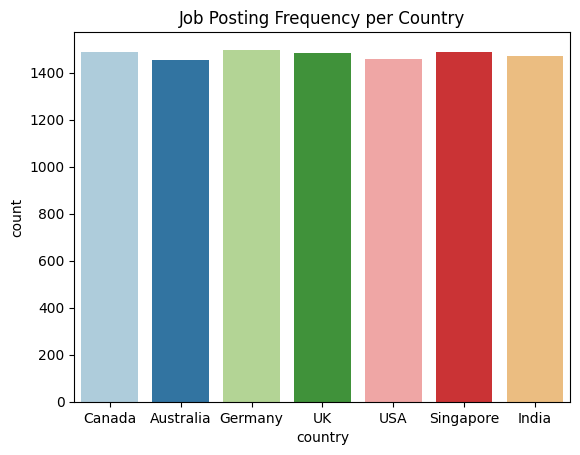

In [3]:
sns.countplot(data=market_data, x='country', hue='country', palette='Paired')
plt.title('Job Posting Frequency per Country')
plt.show()

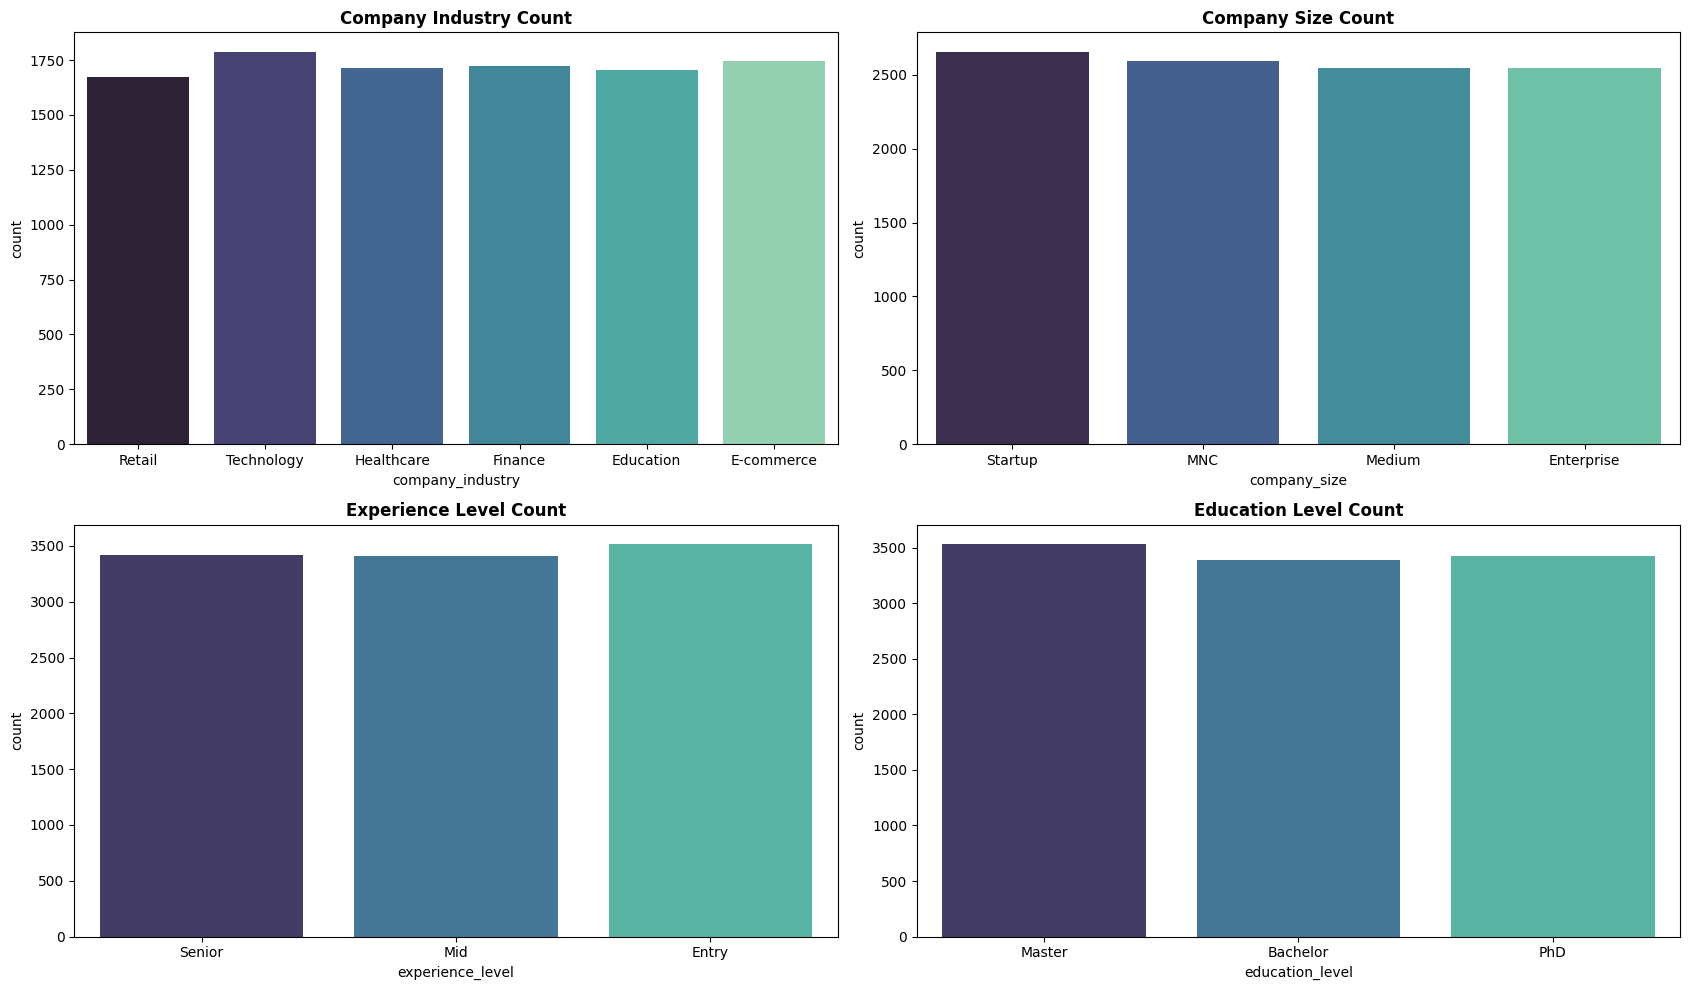

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(17, 10))
axes = axes.flatten()

sns.countplot(data=market_data, x='company_industry', hue='company_industry', ax=axes[0], palette='mako')
axes[0].set_title('Company Industry Count', fontweight="bold")

sns.countplot(data=market_data, x='company_size', hue='company_size', ax=axes[1], palette='mako')
axes[1].set_title('Company Size Count', fontweight="bold")

sns.countplot(data=market_data, x="experience_level", hue="experience_level", ax=axes[2], palette='mako')
axes[2].set_title('Experience Level Count', fontweight="bold")

sns.countplot(data=market_data, x="education_level", hue="education_level", ax=axes[3], palette='mako')
axes[3].set_title('Education Level Count', fontweight="bold")

plt.tight_layout()
plt.show()

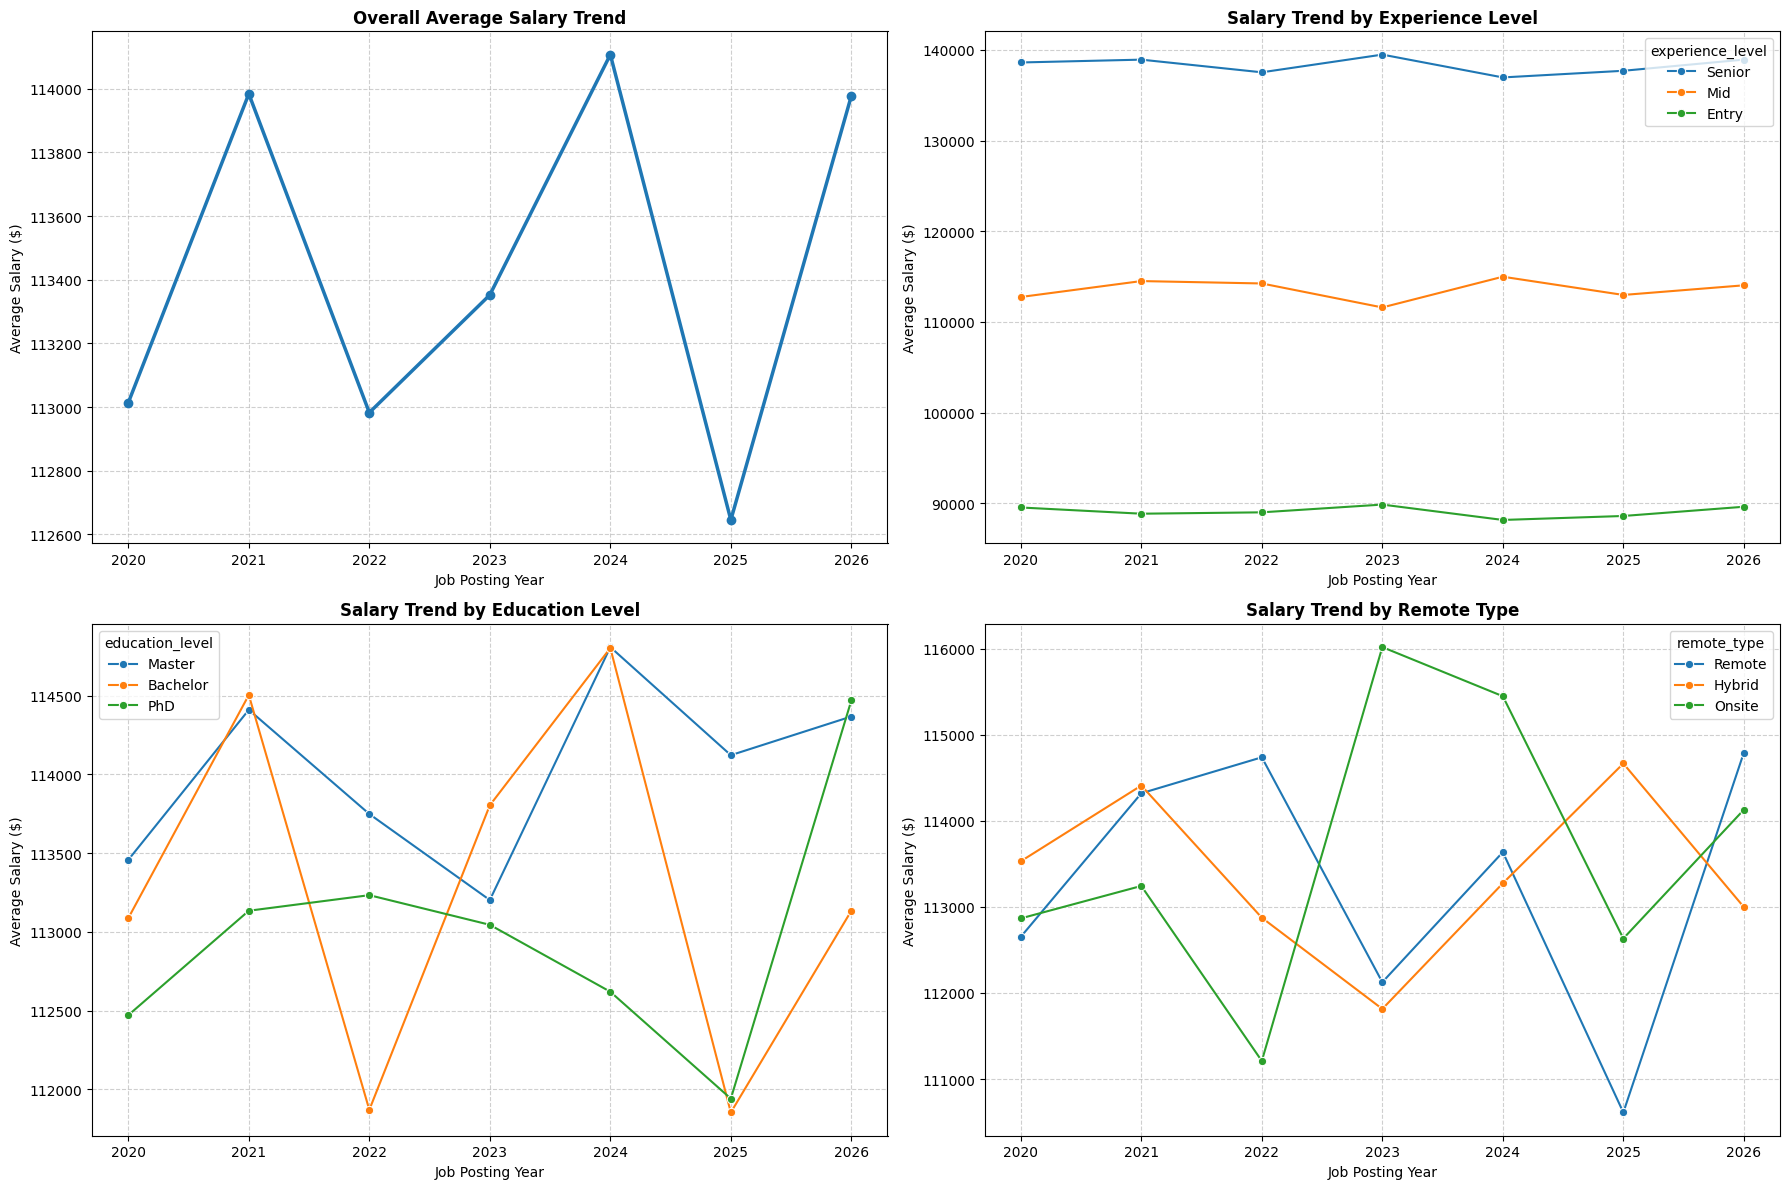

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

# Plot 1: Overall Average Salary Trend
yearly_trend = market_data.groupby("job_posting_year")["salary"].mean().reset_index()
axes[0].plot(
    yearly_trend["job_posting_year"],
    yearly_trend["salary"],
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
)
axes[0].set_title("Overall Average Salary Trend", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Average Salary ($)")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: Salary Trend by Experience Level
sns.lineplot(
    data=market_data,
    x="job_posting_year",
    y="salary",
    hue="experience_level",
    marker="o",
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Salary Trend by Experience Level", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Average Salary ($)")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot 3: Salary Trend by Education Level
sns.lineplot(
    data=market_data,
    x="job_posting_year",
    y="salary",
    hue="education_level",
    marker="o",
    errorbar=None,
    ax=axes[2],
)
axes[2].set_title("Salary Trend by Education Level", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Average Salary ($)")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Plot 4: Salary Trend by Remote Type (or Company Size / Job Title)
sns.lineplot(
    data=market_data,
    x="job_posting_year",
    y="salary",
    hue="remote_type",
    marker="o",
    errorbar=None,
    ax=axes[3],
)
axes[3].set_title("Salary Trend by Remote Type", fontsize=12, fontweight="bold")
axes[3].set_ylabel("Average Salary ($)")
axes[3].grid(True, linestyle="--", alpha=0.6)

for ax in axes:
    ax.set_xlabel("Job Posting Year")
    ax.set_xticks(market_data["job_posting_year"].unique())

plt.tight_layout()
plt.show()

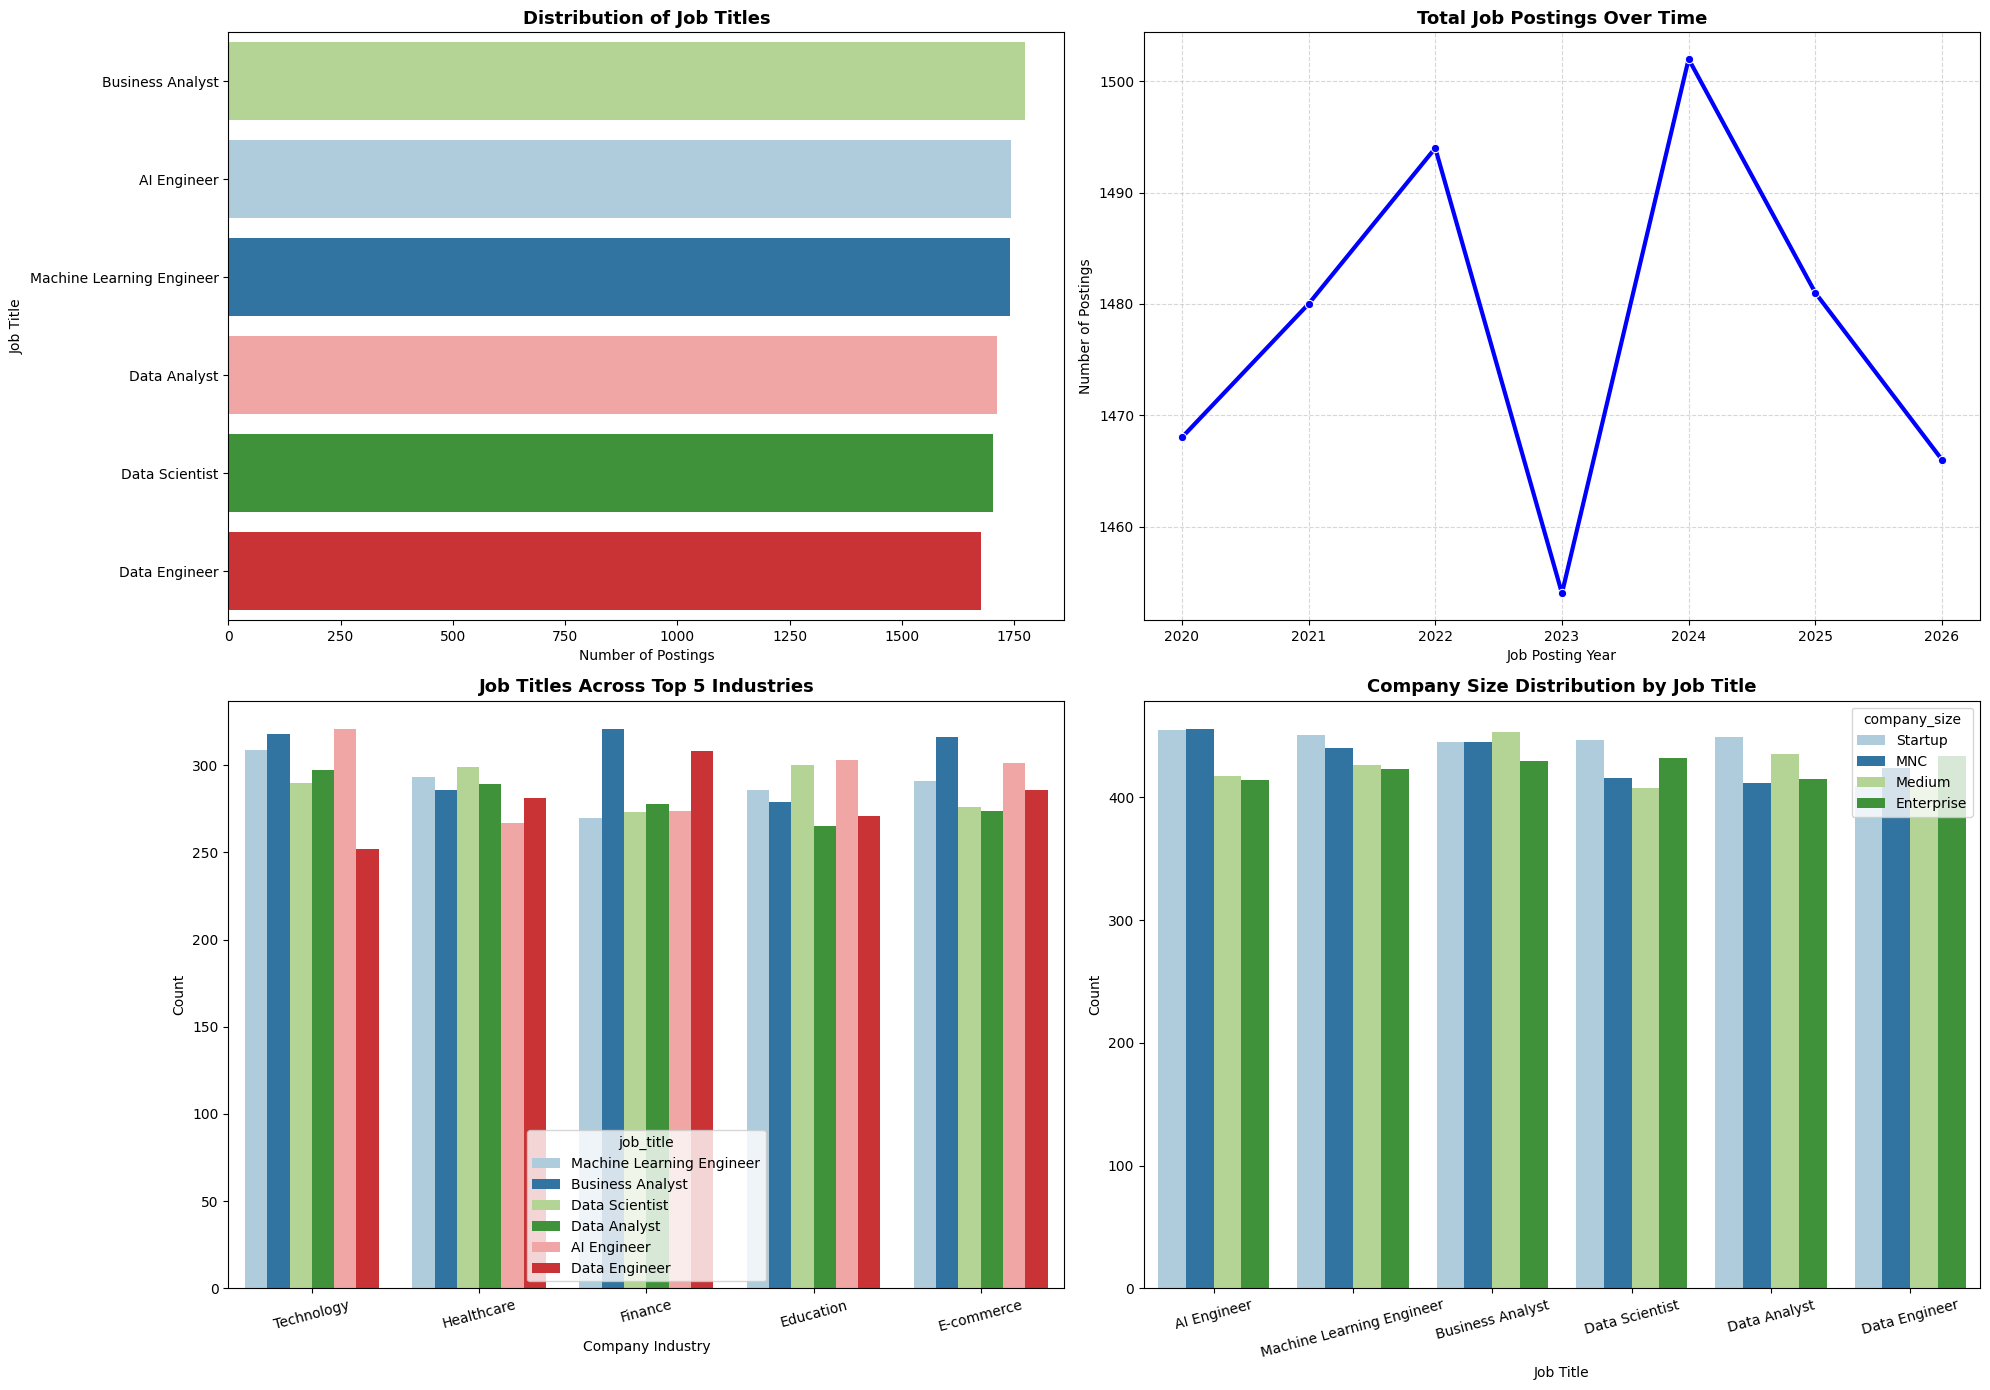

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
axes = axes.flatten()

# Most Common Job Titles (Overall Demand)
sns.countplot(
    data=market_data,
    y="job_title",
    hue="job_title",
    palette="Paired",
    order=market_data["job_title"].value_counts().index,
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Distribution of Job Titles", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Postings")
axes[0].set_ylabel("Job Title")

# Job Frequency Over the Years
# Calculate counts per year to make a clean trend line
job_counts_by_year = (
    market_data.groupby("job_posting_year").size().reset_index(name="count")
)
sns.lineplot(
    data=job_counts_by_year,
    x="job_posting_year",
    y="count",
    marker="o",
    linewidth=3,
    color="#0000FF",
    ax=axes[1],
)
axes[1].set_title("Total Job Postings Over Time", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Job Posting Year")
axes[1].set_ylabel("Number of Postings")
axes[1].set_xticks(market_data["job_posting_year"].unique())
axes[1].grid(True, linestyle="--", alpha=0.5)

# Job Distribution Across Industries (Top 5 Industries)
top_industries = market_data["company_industry"].value_counts().nlargest(5).index
sns.countplot(
    data=market_data[market_data["company_industry"].isin(top_industries)],
    x="company_industry",
    hue="job_title",
    palette="Paired",
    ax=axes[2],
)
axes[2].set_title(
    "Job Titles Across Top 5 Industries", fontsize=13, fontweight="bold"
)
axes[2].set_xlabel("Company Industry")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=15)

# Company Size Breakdowns per Job Title
sns.countplot(
    data=market_data, x="job_title", hue="company_size", palette="Paired", ax=axes[3]
)
axes[3].set_title("Company Size Distribution by Job Title", fontsize=13, fontweight="bold")
axes[3].set_xlabel("Job Title")
axes[3].set_ylabel("Count")
axes[3].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()